In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue','gray', 'Tab:red', 'gray']
seven = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red']
nine = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red', 'Tab:red']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']

In [35]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (3, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# ephys analysis

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[(df.Gal_positive == 'Unknown') & (df.Behaviour_6hFD != 'Pre')]])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [5]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [6]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


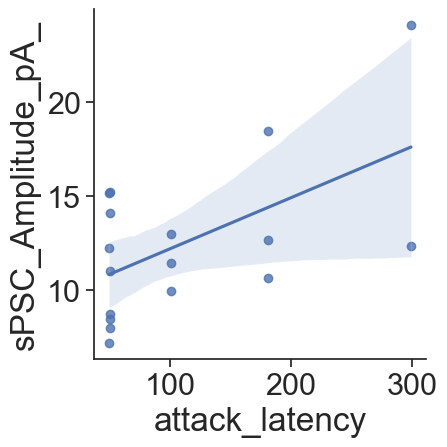

In [7]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [8]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.3281720568429347
Cm(pF) ('Pre', 'Agg-') 0.5290508623404895
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.05827899141391609
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.050500440681557957
Firing_freq_(Hz)_I0 ('Pre', 'npykd') 0.41254486462380224
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.0007392103156646884
Firing_freq_(Hz)_I0 ('Agg+', 'npykd') 0.026735672074107823
Firing_freq_(Hz)_I0 ('Agg-', 'npykd') 0.4616941577464172
Behaviour_6hFD
Agg+     0.420500
Agg-     2.212273
Pre      1.642000
npykd    1.998947
Name: Firing_freq_(Hz)_I0, dtype: float64


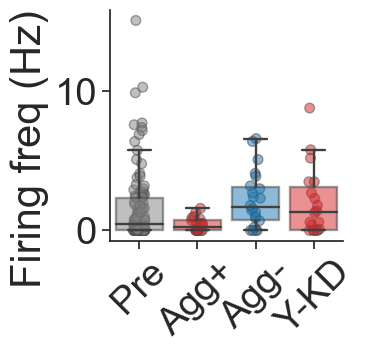

Instant_freq_(Hz) ('Pre', 'Agg+') 0.04484084618056422
Instant_freq_(Hz) ('Pre', 'Agg-') 0.13791987695468466
Instant_freq_(Hz) ('Pre', 'npykd') 0.3928748109158061
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.002544867996855417
Instant_freq_(Hz) ('Agg+', 'npykd') 0.03308260548978594
Instant_freq_(Hz) ('Agg-', 'npykd') 0.6740294749319313
Behaviour_6hFD
Agg+     0.744500
Agg-     2.549545
Pre      2.028381
npykd    2.491579
Name: Instant_freq_(Hz), dtype: float64


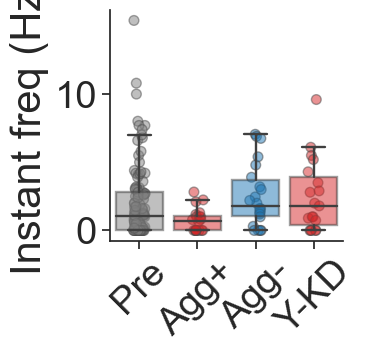

isi_(ms) ('Pre', 'Agg+') 0.2637732659798634
isi_(ms) ('Pre', 'Agg-') 0.054024744647440136
isi_(ms) ('Pre', 'npykd') 0.21863741859661434
isi_(ms) ('Agg+', 'Agg-') 0.0009545895802604041
isi_(ms) ('Agg+', 'npykd') 0.026611609943789957
isi_(ms) ('Agg-', 'npykd') 0.6899948772616324
Behaviour_6hFD
Agg+     1889.090909
Agg-      748.955556
Pre      3825.349342
npykd    1532.478571
Name: isi_(ms), dtype: float64


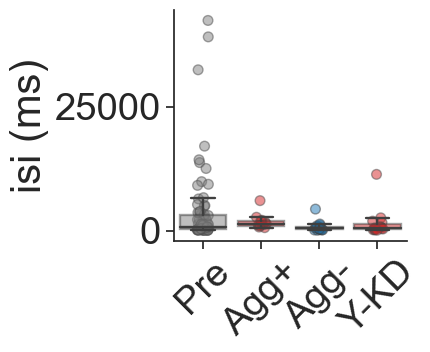

CaT ('Pre', 'Agg+') 0.5124169496652511
CaT ('Pre', 'Agg-') 0.3954543611558381
CaT ('Pre', 'npykd') 0.358546467067407
CaT ('Agg+', 'Agg-') 0.22500730635249944
CaT ('Agg+', 'npykd') 0.880181579041291
CaT ('Agg-', 'npykd') 0.13214757065294017
Behaviour_6hFD
Agg+     4.801053
Agg-     5.747273
Pre      5.908272
npykd    3.876842
Name: CaT, dtype: float64


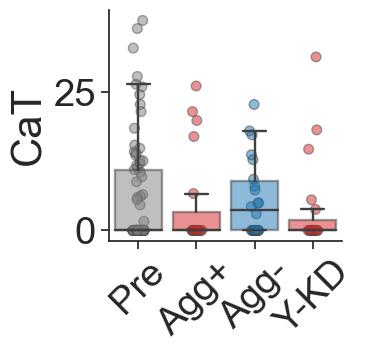

Ih_at_-120mV ('Pre', 'Agg+') 0.03248478615014375
Ih_at_-120mV ('Pre', 'Agg-') 0.5161858338475181
Ih_at_-120mV ('Pre', 'npykd') 0.7826807726915641
Ih_at_-120mV ('Agg+', 'Agg-') 0.003293378041489342
Ih_at_-120mV ('Agg+', 'npykd') 0.023913065919995057
Ih_at_-120mV ('Agg-', 'npykd') 0.8650353939353734
Behaviour_6hFD
Agg+     3.182105
Agg-     7.454091
Pre      6.961585
npykd    6.463684
Name: Ih_at_-120mV, dtype: float64


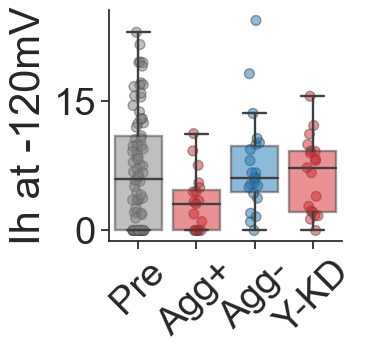

AP_ampl ('Pre', 'Agg+') 0.7364732348111037
AP_ampl ('Pre', 'Agg-') 0.6484995979902848
AP_ampl ('Pre', 'npykd') 0.013079101732619993
AP_ampl ('Agg+', 'Agg-') 0.8749979379042403
AP_ampl ('Agg+', 'npykd') 0.058932211586345255
AP_ampl ('Agg-', 'npykd') 0.07117241510559746
Behaviour_6hFD
Agg+     90.153636
Agg-     88.562778
Pre      90.788689
npykd    76.807143
Name: AP_ampl, dtype: float64


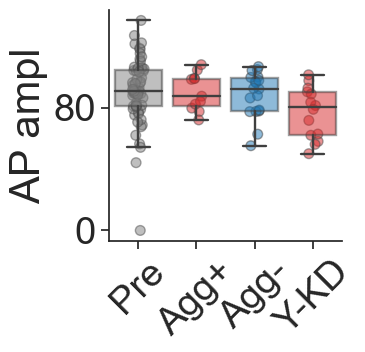

AP_halfwidth ('Pre', 'Agg+') 0.6334908387740781
AP_halfwidth ('Pre', 'Agg-') 0.04959538934130666
AP_halfwidth ('Pre', 'npykd') 0.3920268022551605
AP_halfwidth ('Agg+', 'Agg-') 0.11004973835429231
AP_halfwidth ('Agg+', 'npykd') 0.8695215390078627
AP_halfwidth ('Agg-', 'npykd') 0.022468620794247395
Behaviour_6hFD
Agg+     3.383636
Agg-     2.132222
Pre      2.794000
npykd    3.114286
Name: AP_halfwidth, dtype: float64


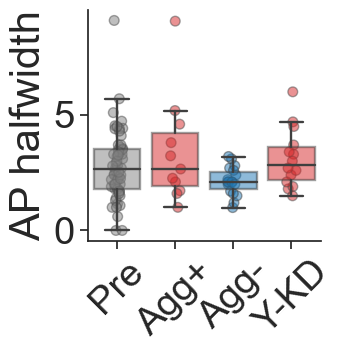

AP_time_to_peak ('Pre', 'Agg+') 0.632894626477718
AP_time_to_peak ('Pre', 'Agg-') 0.8469049089292453
AP_time_to_peak ('Pre', 'npykd') 0.05672707790054181
AP_time_to_peak ('Agg+', 'Agg-') 0.5285734197255108
AP_time_to_peak ('Agg+', 'npykd') 0.19809428338334245
AP_time_to_peak ('Agg-', 'npykd') 0.03791172382938484
Behaviour_6hFD
Agg+     2.349091
Agg-     1.992222
Pre      2.541311
npykd    2.571429
Name: AP_time_to_peak, dtype: float64


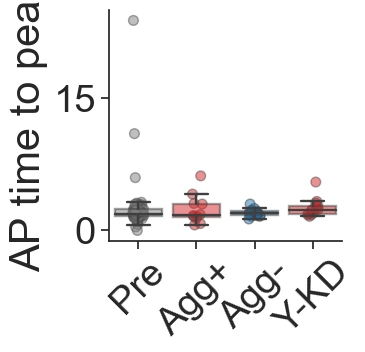

area(mV_ms) ('Pre', 'Agg+') 0.7130027575590088
area(mV_ms) ('Pre', 'Agg-') 0.016837642364698622
area(mV_ms) ('Pre', 'npykd') 0.22361441127917991
area(mV_ms) ('Agg+', 'Agg-') 0.17041453269533946
area(mV_ms) ('Agg+', 'npykd') 0.39613407861584393
area(mV_ms) ('Agg-', 'npykd') 0.19001098064722566
Behaviour_6hFD
Agg+     292.545455
Agg-     212.050000
Pre      281.336066
npykd    235.064286
Name: area(mV_ms), dtype: float64


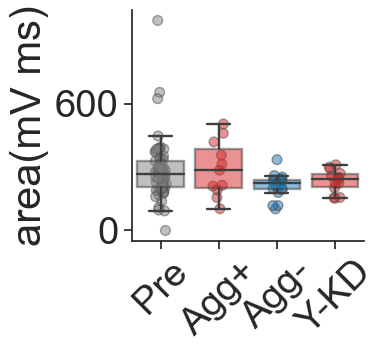

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.5789840240104309
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.14643851650205936
rheobase_at_-60mV_(pA) ('Pre', 'npykd') 0.15986948030466852
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.5964378125323442
rheobase_at_-60mV_(pA) ('Agg+', 'npykd') 0.9513460710428313
rheobase_at_-60mV_(pA) ('Agg-', 'npykd') 0.9661887794565777
Behaviour_6hFD
Agg+     22.105263
Agg-     21.904762
Pre      15.688525
npykd    15.277778
Name: rheobase_at_-60mV_(pA), dtype: float64


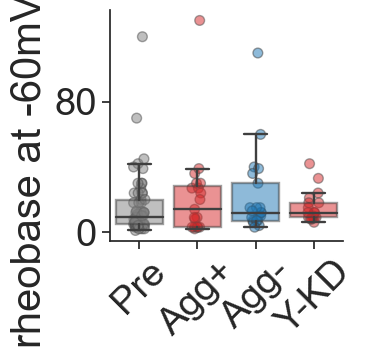

AHP_(mV) ('Pre', 'Agg+') 0.8674712821649249
AHP_(mV) ('Pre', 'Agg-') 0.682407498428275
AHP_(mV) ('Pre', 'npykd') 1.9186906844469742e-06
AHP_(mV) ('Agg+', 'Agg-') 0.8047247609743855
AHP_(mV) ('Agg+', 'npykd') 9.039948504341842e-05
AHP_(mV) ('Agg-', 'npykd') 2.280084288246825e-05
Behaviour_6hFD
Agg+    -53.024545
Agg-    -52.755556
Pre     -52.867000
npykd   -41.414286
Name: AHP_(mV), dtype: float64


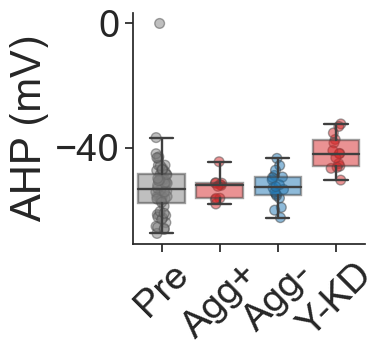

Vm ('Pre', 'Agg+') 0.8464739279102969
Vm ('Pre', 'Agg-') 0.5059726708502595
Vm ('Pre', 'npykd') 2.454085315453548e-07
Vm ('Agg+', 'Agg-') 0.6233599328013222
Vm ('Agg+', 'npykd') 5.530373549353605e-05
Vm ('Agg-', 'npykd') 0.0001423765574549236
Behaviour_6hFD
Agg+    -47.896130
Agg-    -45.997810
Pre     -46.720754
npykd   -35.749875
Name: Vm, dtype: float64


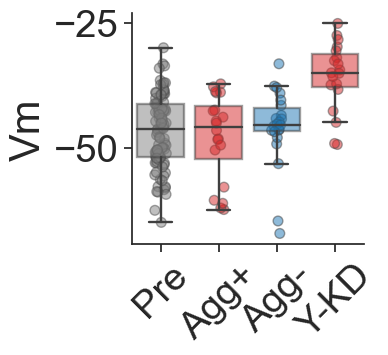

Input_Resistance ('Pre', 'Agg+') 0.006277492855837799
Input_Resistance ('Pre', 'Agg-') 0.7897476721570257
Input_Resistance ('Pre', 'npykd') 0.0003159029724099908
Input_Resistance ('Agg+', 'Agg-') 0.02372916549853407
Input_Resistance ('Agg+', 'npykd') 0.30686792369038496
Input_Resistance ('Agg-', 'npykd') 0.003003459393580646
Behaviour_6hFD
Agg+     766.245295
Agg-     605.318491
Pre      625.751903
npykd    796.936172
Name: Input_Resistance, dtype: float64


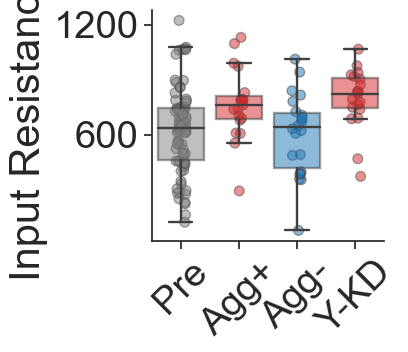

sPSC_frequency ('Pre', 'Agg+') 0.40813528014265654
sPSC_frequency ('Pre', 'Agg-') 0.16569340327720272
sPSC_frequency ('Pre', 'npykd') 0.20804138748350864
sPSC_frequency ('Agg+', 'Agg-') 0.7613431829082835
sPSC_frequency ('Agg+', 'npykd') 0.10748822968805012
sPSC_frequency ('Agg-', 'npykd') 0.03712596135002326
Behaviour_6hFD
Agg+     2.090856
Agg-     1.441626
Pre      2.128957
npykd    2.988168
Name: sPSC_frequency, dtype: float64


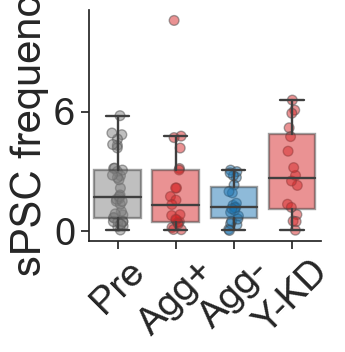

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8686008852328163
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.025875307502539382
sPSC_Amplitude(pA) ('Pre', 'npykd') 0.11270055095908209
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.05028955023126193
sPSC_Amplitude(pA) ('Agg+', 'npykd') 0.14533570038081495
sPSC_Amplitude(pA) ('Agg-', 'npykd') 0.7673071155556084
Behaviour_6hFD
Agg+     12.477348
Agg-     11.552273
Pre      12.496183
npykd    10.693750
Name: sPSC_Amplitude(pA), dtype: float64


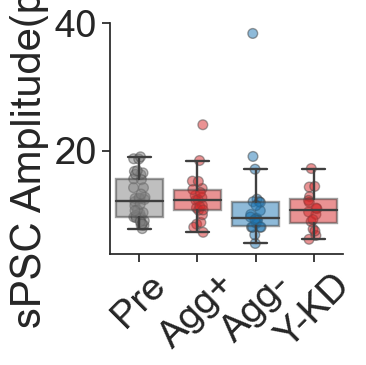

sPSCs_Rise time ('Pre', 'Agg+') 0.7063568362202246
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203
sPSCs_Rise time ('Pre', 'npykd') 0.5689142610570352
sPSCs_Rise time ('Agg+', 'Agg-') 0.22185046852722268
sPSCs_Rise time ('Agg+', 'npykd') 0.3936976118002311
sPSCs_Rise time ('Agg-', 'npykd') 0.8003315640351998
Behaviour_6hFD
Agg+     1.209524
Agg-     1.300000
Pre      1.178788
npykd    1.200000
Name: sPSCs_Rise time, dtype: float64


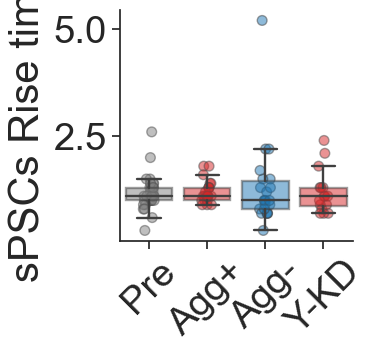

sPSCs (decay) ('Pre', 'Agg+') 0.8556903153556764
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079
sPSCs (decay) ('Pre', 'npykd') 0.457048180309247
sPSCs (decay) ('Agg+', 'Agg-') 0.4890208851693393
sPSCs (decay) ('Agg+', 'npykd') 0.19254896256924658
sPSCs (decay) ('Agg-', 'npykd') 0.6344757646596549
Behaviour_6hFD
Agg+     10.041414
Agg-      9.619048
Pre       9.373997
npykd    10.718750
Name: sPSCs (decay), dtype: float64


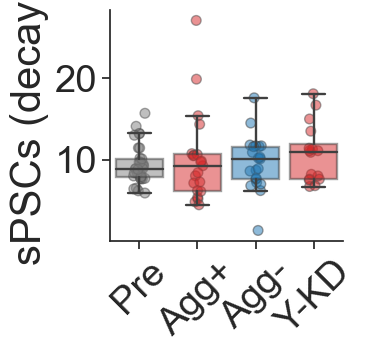

In [36]:
# filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy_antag', 'npy1r_antag', 'npy2r_antag' ,'ZD7288']

# # set categorical variables
# ephys['Behaviour_6hFD'] = pd.Categorical(ephys['Behaviour_6hFD'], categories=filter_cat, ordered=True)


# preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
#                 palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Tab:red', 'Gray'], order = filter_cat,
#                   plotting= True)


## Individual plots - panMPOA

In [11]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

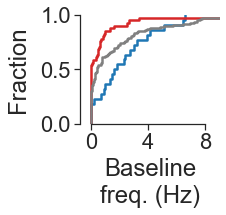

In [12]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [13]:
# Stats
ephys2_pre = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Pre', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_agg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg+', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_noagg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg-', 'Firing_freq_(Hz)_I0'].dropna()

from scipy.stats import mannwhitneyu

# Pre vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)
# Pre vs Agg-
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_noagg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg-:", p_value)
# Agg- vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_noagg, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Agg- vs Agg+:", p_value)

Mann-Whitney U Statistic: 2655.0
P-value Pre vs Agg+: 0.00504719432915003
Mann-Whitney U Statistic: 815.5
P-value Pre vs Agg-: 0.056508303792092644
Mann-Whitney U Statistic: 702.5
P-value Agg- vs Agg+: 0.0001746705231566079


In [14]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

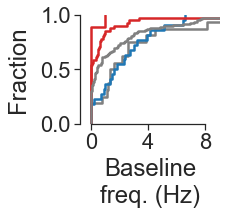

In [15]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

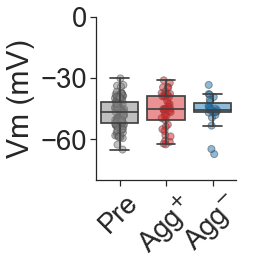

In [16]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [17]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

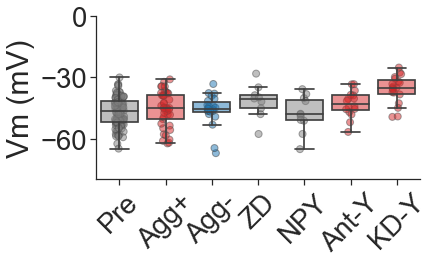

In [18]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [19]:
# ephys.Behaviour_6hFD.unique()

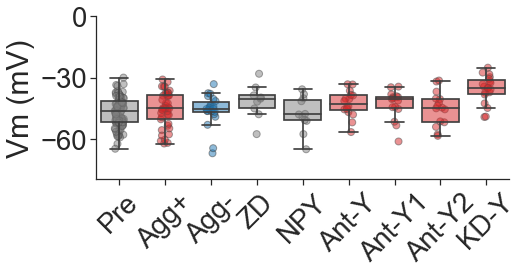

In [20]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS INCL. Y1/Y2 ANT

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

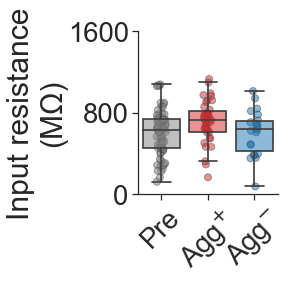

In [21]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Input resistance\n(MΩ)', labelpad=0)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

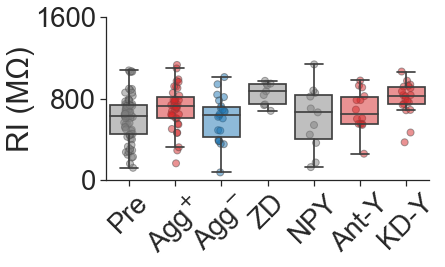

In [22]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

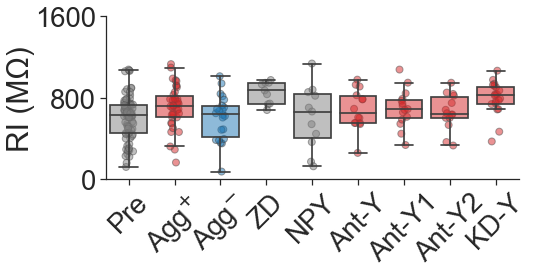

In [23]:
# Input resistance - VERSION WITH ALL GROUPS INCL Y1/2

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [24]:
# cell numbers
group_counts = ephys['Behaviour_6hFD'].value_counts()
print(group_counts)
# mice per group
unique_id_counts = ephys.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
print(unique_id_counts)

Pre               102
Agg+               43
Agg-               22
npykd              19
npy_antag          17
npy1r_antag        15
npy2r_antag        15
agrp_100           15
npy_100            11
npy_10             10
ZD7288              9
npy_10_paired       6
ZD7288_20           5
npy_100_paired      4
Name: Behaviour_6hFD, dtype: int64
Behaviour_6hFD
Agg+              11
Agg-               3
Pre               12
ZD7288             1
ZD7288_20          1
agrp_100           5
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     0
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64


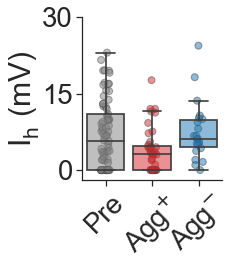

In [25]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

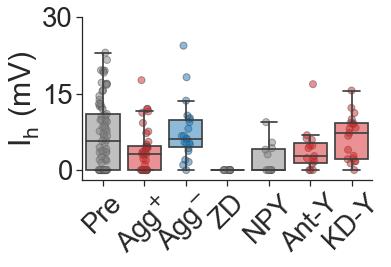

In [26]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

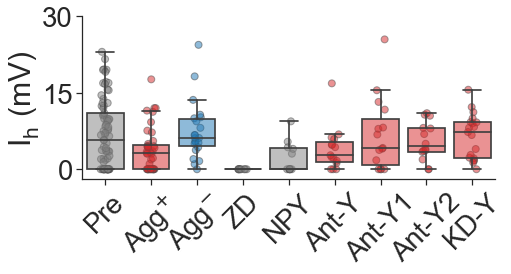

In [27]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2' ,'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

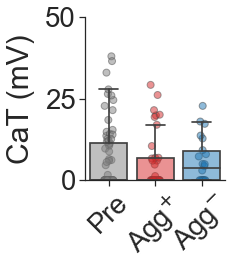

In [28]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

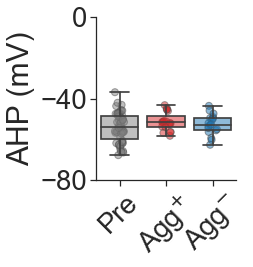

In [29]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

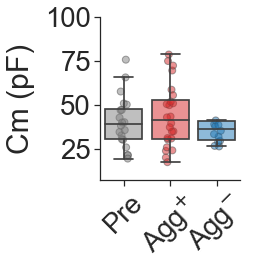

In [30]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

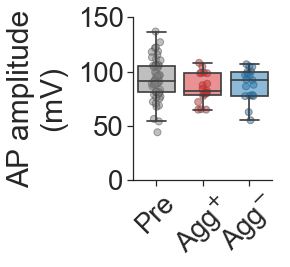

In [31]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

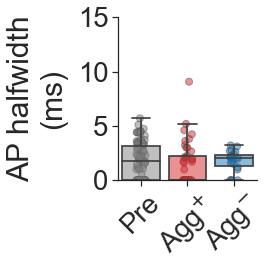

In [32]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

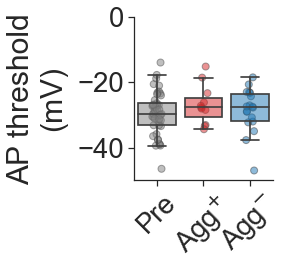

In [33]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/AP threshold/APthreshold_v1.csv')

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP threshold\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

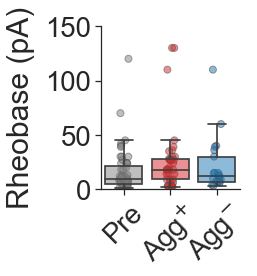

In [34]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

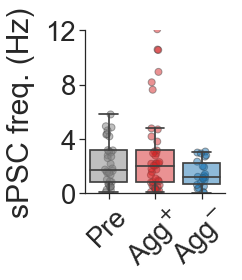

In [35]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. (Hz)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,12)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

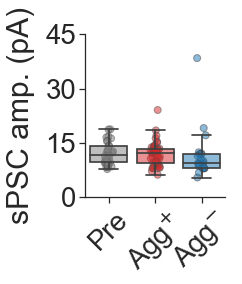

In [36]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. (pA)', labelpad=10)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

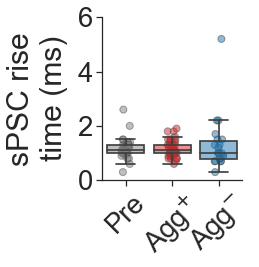

In [37]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

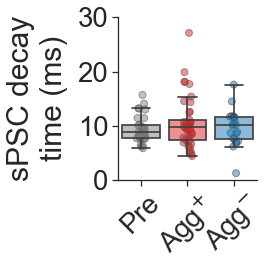

In [38]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Gal+ vs Gal-

In [39]:
gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
gals = pd.concat([gal,no_gal], axis = 0)
len(no_gal)

10

In [40]:
count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

Number of Gal+ (Agg+) cells: 11
Number of Gal- (Agg+) cells: 10


Cm(pF) ('yes', 'no') 0.7301587301587302
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


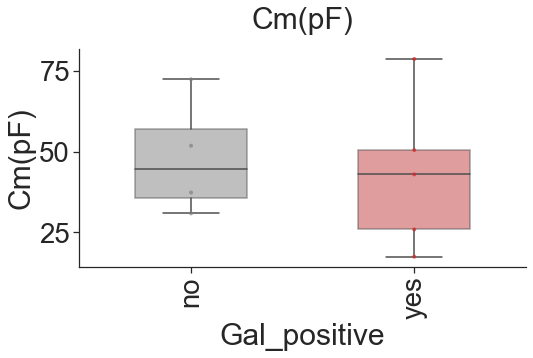

Firing_freq_(Hz)_I0 ('yes', 'no') 1.0
Gal_positive
no     1.326000
yes    0.663636
Name: Firing_freq_(Hz)_I0, dtype: float64


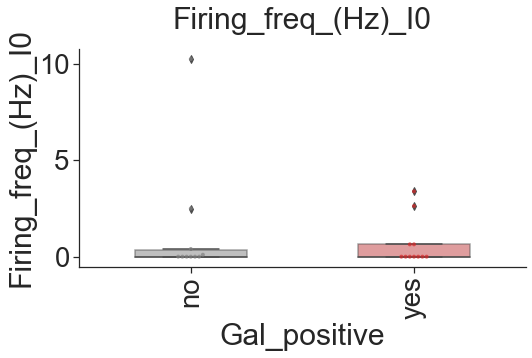

Instant_freq_(Hz) ('yes', 'no') 1.0
Gal_positive
no     1.470000
yes    0.812727
Name: Instant_freq_(Hz), dtype: float64


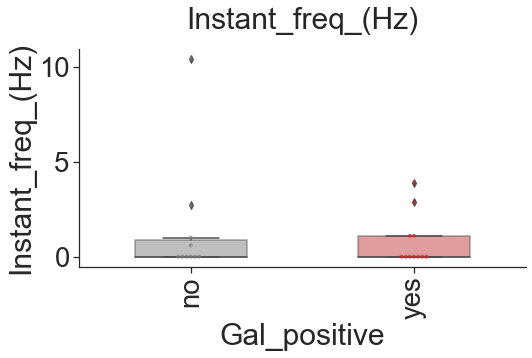

isi_(ms) ('yes', 'no') 0.6631172453203822
Gal_positive
no     3117.855
yes     942.500
Name: isi_(ms), dtype: float64


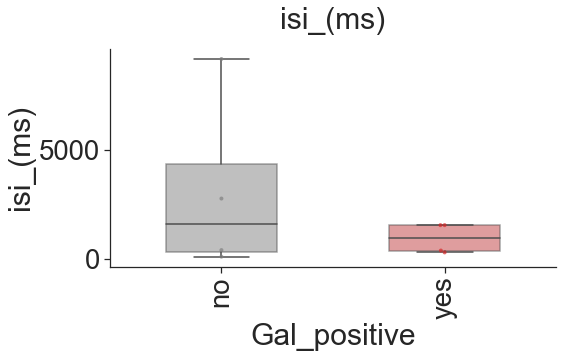

CaT ('yes', 'no') 0.36427987734677436
Gal_positive
no     8.533000
yes    2.866667
Name: CaT, dtype: float64


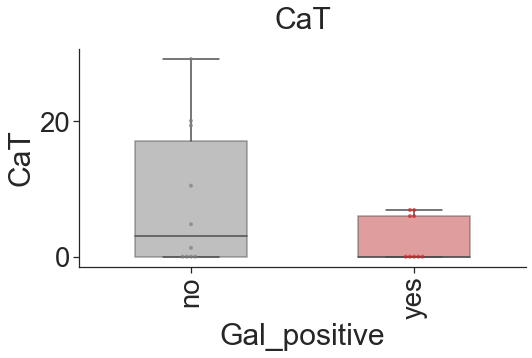

Ih_at_-120mV ('yes', 'no') 0.90769560772689
Gal_positive
no     3.844
yes    5.128
Name: Ih_at_-120mV, dtype: float64


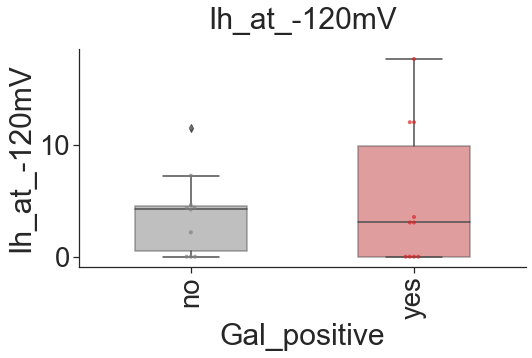

AP_ampl ('yes', 'no') 0.05907186801551649
Gal_positive
no     86.8000
yes    68.9375
Name: AP_ampl, dtype: float64


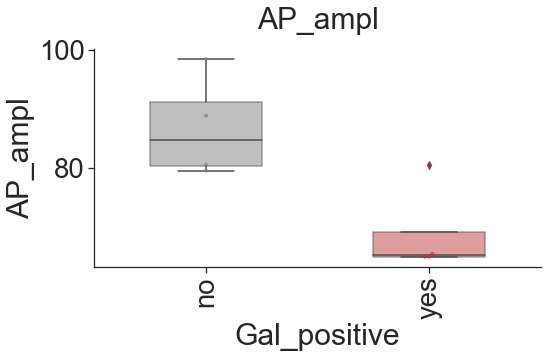

AP_halfwidth ('yes', 'no') 0.029401048190339642
Gal_positive
no     1.9275
yes    3.4600
Name: AP_halfwidth, dtype: float64


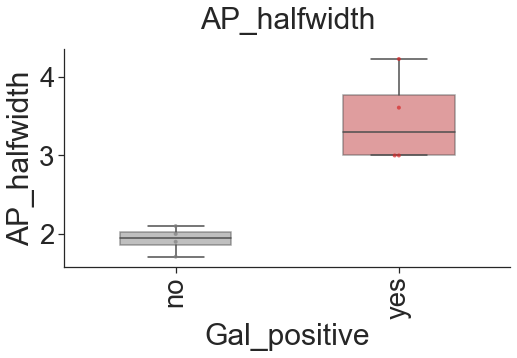

AP_time_to_peak ('yes', 'no') 0.19126698687886878
Gal_positive
no     1.5050
yes    2.1225
Name: AP_time_to_peak, dtype: float64


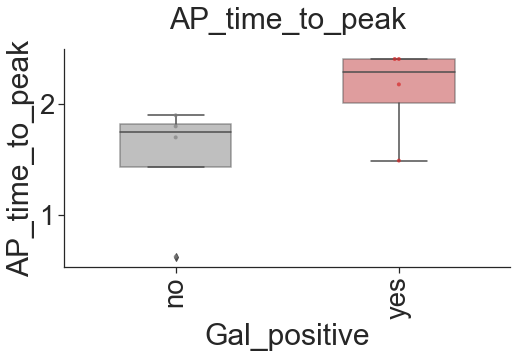

area(mV_ms) ('yes', 'no') 0.19126698687886878
Gal_positive
no     179.475
yes    231.400
Name: area(mV_ms), dtype: float64


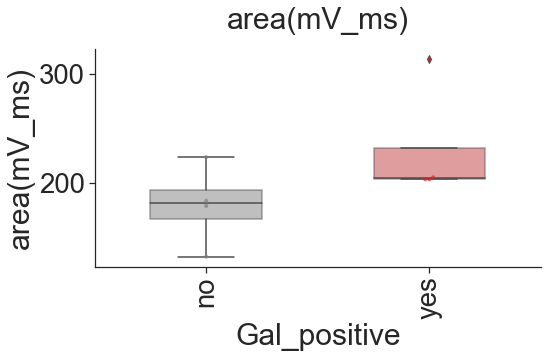

rheobase_at_-60mV_(pA) ('yes', 'no') 0.7528319675807176
Gal_positive
no     44.625
yes    20.900
Name: rheobase_at_-60mV_(pA), dtype: float64


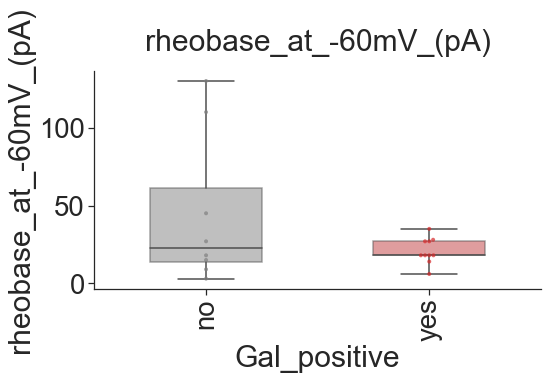

AHP_(mV) ('yes', 'no') 0.029401048190339642
Gal_positive
no    -52.4500
yes   -44.9375
Name: AHP_(mV), dtype: float64


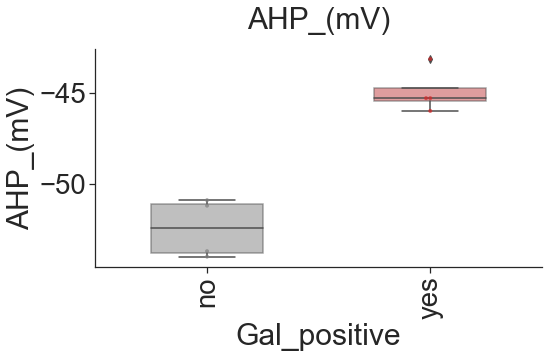

Vm ('yes', 'no') 0.09774292974941272
Gal_positive
no    -46.908149
yes   -39.901888
Name: Vm, dtype: float64


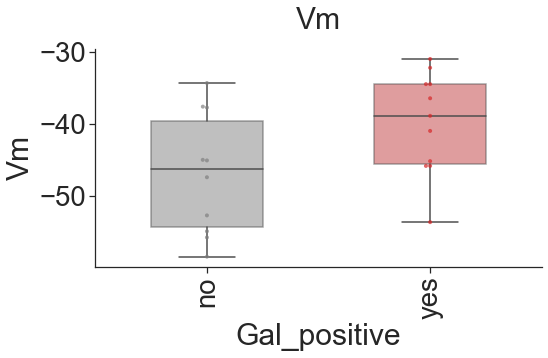

Input_Resistance ('yes', 'no') 0.7748591175148819
Gal_positive
no     665.622933
yes    655.402328
Name: Input_Resistance, dtype: float64


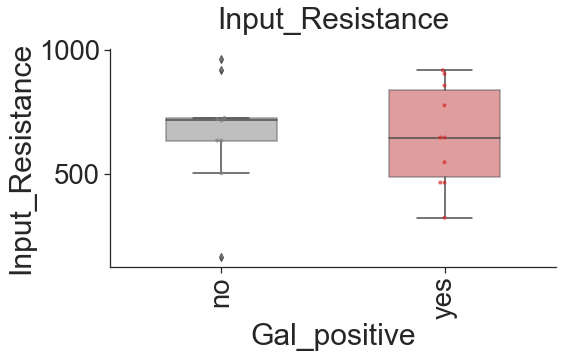

sPSC_frequency ('yes', 'no') 0.287132738955737
Gal_positive
no     4.908518
yes    2.877295
Name: sPSC_frequency, dtype: float64


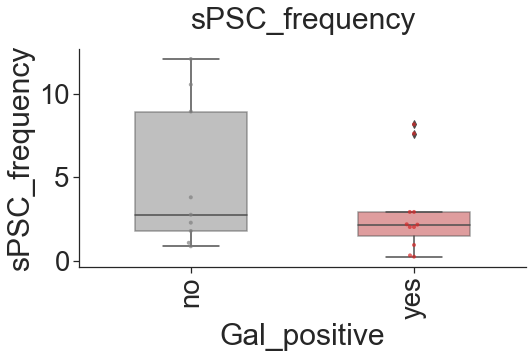

sPSC_Amplitude(pA) ('yes', 'no') 0.36157352238579643
Gal_positive
no     12.370000
yes    10.884545
Name: sPSC_Amplitude(pA), dtype: float64


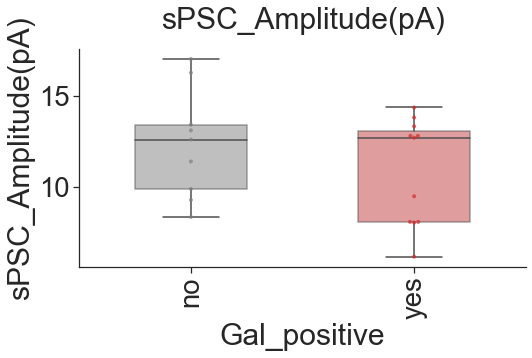

sPSCs_Rise time ('yes', 'no') 0.9078437073284262
Gal_positive
no     1.066667
yes    1.136364
Name: sPSCs_Rise time, dtype: float64


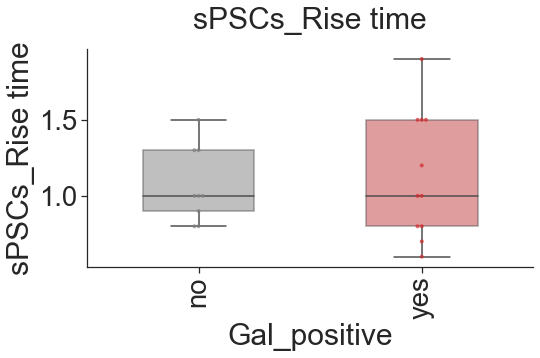

sPSCs (decay) ('yes', 'no') 0.0400886369761031
Gal_positive
no      9.096667
yes    12.559091
Name: sPSCs (decay), dtype: float64


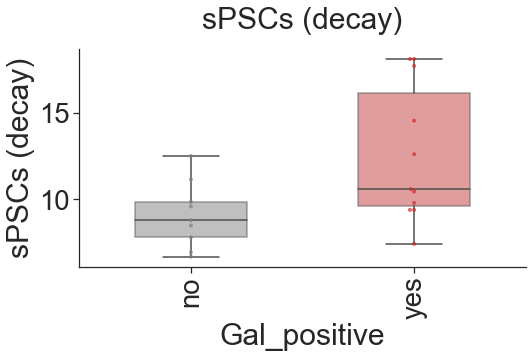

In [41]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
                'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [42]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,4.252817e+05,1.0,9.013023,0.003262
Residual,5.662229e+06,120.0,NaN,NaN


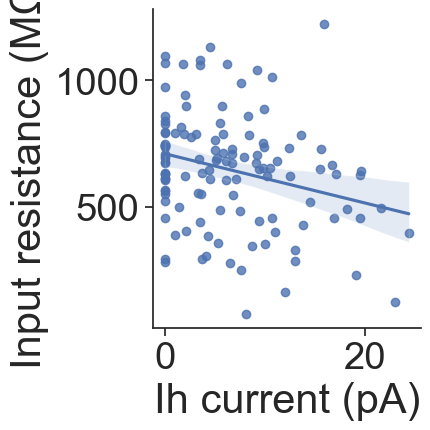

In [11]:
print("Coefficient of determination (R^2):", model.rsquared)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


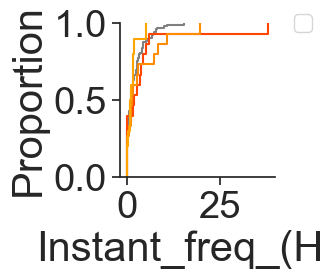

In [12]:
# sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
# plt.xlabel('Ih current (pA)')
# plt.ylabel('Input resistance (MΩ)')
# plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


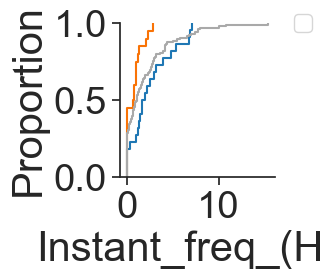

In [13]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

### Individual plots Gal+ vs Gal-

In [14]:
gals = df[(df.Gal_positive.isin(['yes', 'no'])) & (df.Behaviour_6hFD != 'Pre')]

In [15]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")

Number of Gal+ neurons: 9 from 3 mice
Number of Gal- neurons: 10 from 4 mice


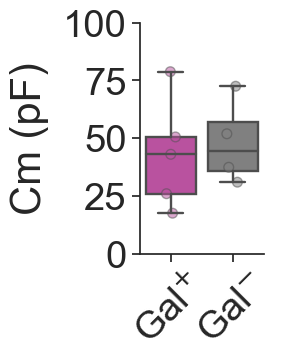

In [16]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [17]:
# gals

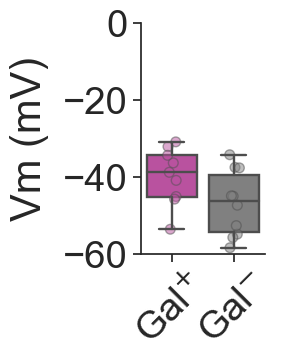

In [18]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

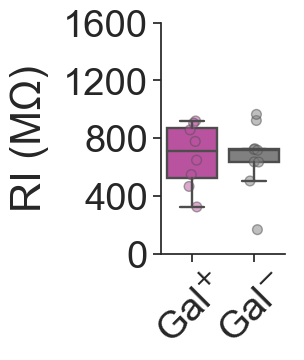

In [19]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

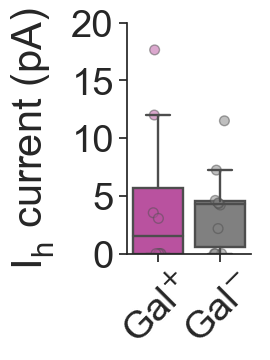

In [20]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ current (pA)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

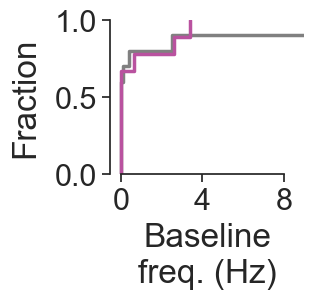

In [21]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## silent proportion

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      8      22     11   41
Agg-                      4       4     14   22
Pre                      18      27     55  100
ZD7288                    0       8      1    9
npy1r_antag               2       3     10   15
npy2r_antag               3       6      6   15
npy_100                   2       7      2   11
npy_antag                 4       3      9   16
npykd                     3       5     11   19
All                      44      85    119  248
0.0032065377362250316


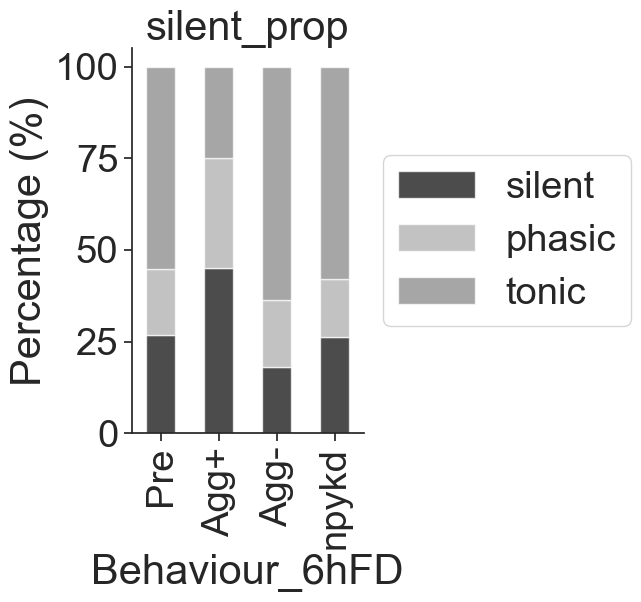

In [45]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100',  'npy_antag','npy1r_antag', 'npy2r_antag', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [42]:
stats.chi2_contingency(silent_prop[cols])

Chi2ContingencyResult(statistic=37.145312005840026, pvalue=1.6496799747187568e-06, dof=6, expected_freq=array([[29.04106858, 20.51663249, 50.44229893],
       [29.04106858, 20.51663249, 50.44229893],
       [29.04106858, 20.51663249, 50.44229893],
       [29.04106858, 20.51663249, 50.44229893]]))

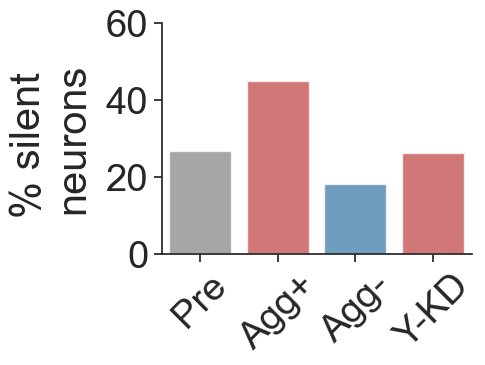

In [43]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                palette = seven, alpha=0.7)
plt.ylabel('% silent neurons', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
xxxx

In [ ]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                palette = nine, alpha=0.7)
plt.ylabel('% silent neurons', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# % silent neurons CHECK WHETHER THESE VALUES ARE CORRECT!

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       6      4   10
yes                1       6      2    9
All                1      12      6   19
0.44518771279268876


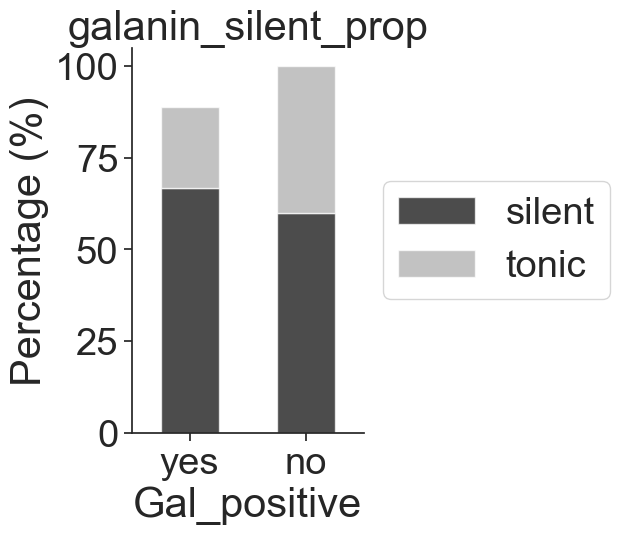

In [26]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

## adaptive prop

In [27]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-',]
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])


Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1   7   12   20
Agg-            0  18    3   21
Pre             1  15   27   43
All             2  40   42   84
0.0021382241674996086


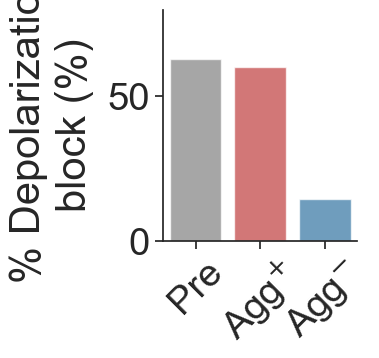

In [28]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% Depolarization\nblock (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=80)
plt.yticks(np.arange(0, 81, 50))
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             5    3    8
yes            3    5    8
All            8    8   16
0.6170750774519739


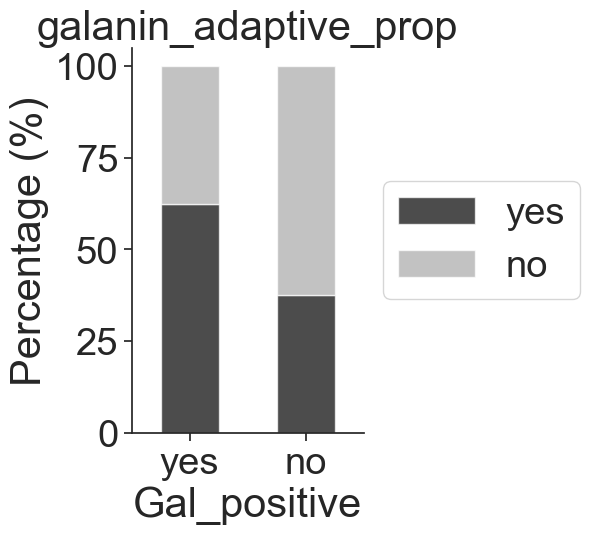

In [29]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             14    0    5     0   19
Agg-              9    1   11     1   22
Pre              51    0   31     0   82
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
npy1r_antag       9    0    6     0   15
npy2r_antag       9    0    5     0   14
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             154    2   77     1  234
0.20151323971527402


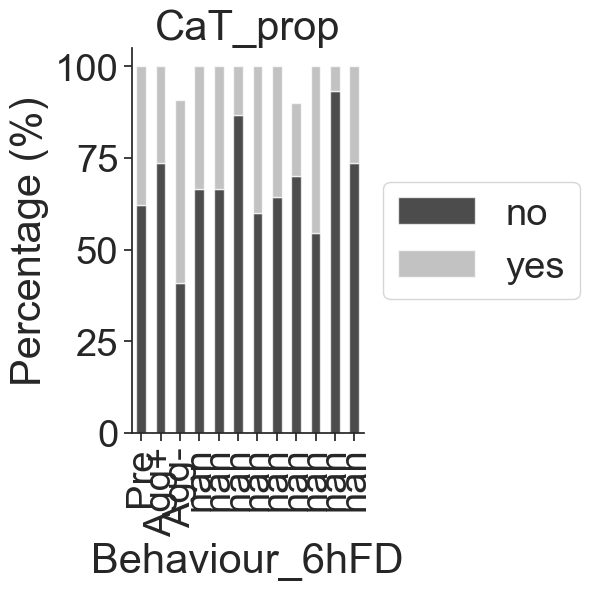

In [30]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             4    6   10
yes            5    3    8
All            9    9   18
0.6352562959972483


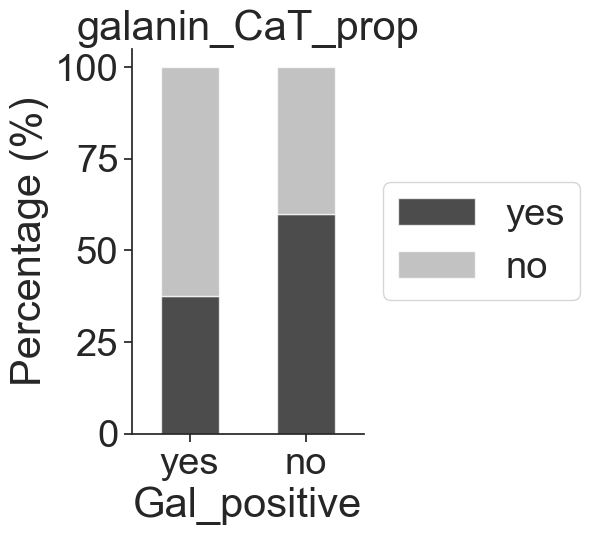

In [31]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+             7   12   19
Agg-             1   21   22
Pre             24   58   82
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             73  169  242
9.489191283131947e-07


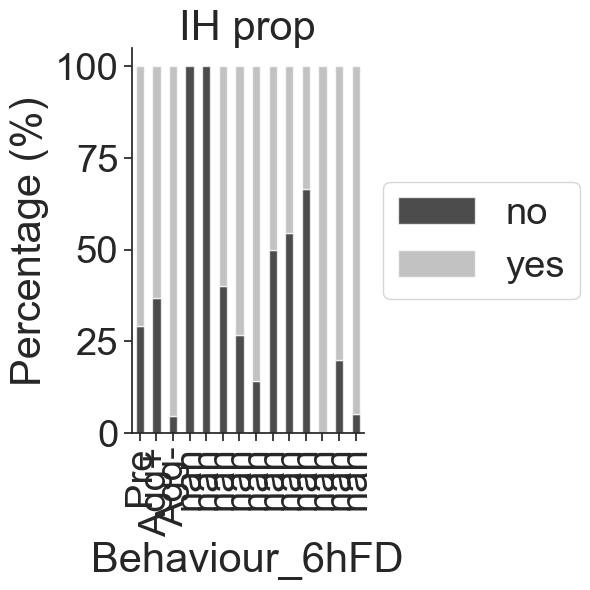

In [32]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                7   36   43
silent               36   49   85
tonic                30   84  114
All                  73  169  242
0.0046740809868728705


Text(0.5, 0, '')

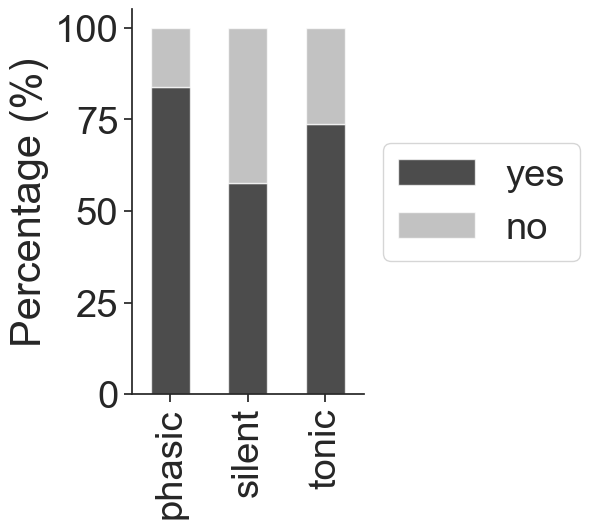

In [33]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis

In [43]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY Antag', 'NPY-KD', 'ZD7288']

ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

else:
    # list all directory in filepath
    df_state = pd.DataFrame()

    for state in states:
        files = [file for file in glob(f'{path}/{state}/*.xlsx')]
        df_files = []
        for file in files:
            try:
                df_file = pd.read_excel(file)
                df_file['filename'] = file
            except ValueError:
                print(file, state)
            df_files.append(df_file)

        df = pd.concat(df_files)
        df['state'] = state
        df_state = pd.concat([df_state, df])

    df_state.to_csv('ramps_all.csv')
    
        

/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp/Agg-/~$S1C4 16102023.xlsx Agg-


In [85]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all = pd.merge(df_all, num_spike, on = ['filename', 'Injected'])




In [86]:
df_all.state.unique()

['Agg+', 'Agg-', 'NPY 10nM', 'NPY Antag', 'NPY-KD', 'Pre', 'ZD7288']
Categories (7, object): ['Pre' < 'Agg+' < 'Agg-' < 'NPY 10nM' < 'NPY Antag' < 'NPY-KD' < 'ZD7288']

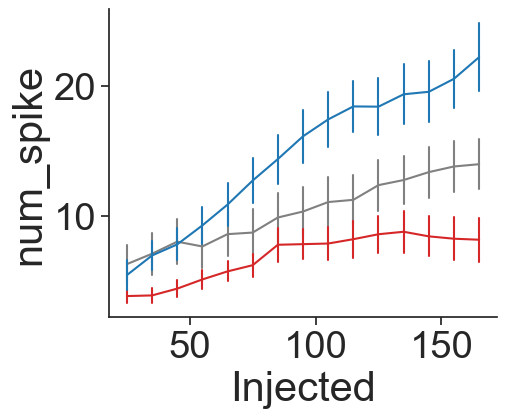

In [90]:
prop = 'num_spike'

plot_df = df_all[df_all.state.isin(['Pre', 'Agg+', 'Agg-'])]
fig, ax = plt.subplots(figsize = [5,4])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", errorbar=("se", 1))

leg = ax.get_legend()
if leg:
    leg.remove()

sns.despine()
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf',dpi=300,bbox_inches='tight', transparent=True)




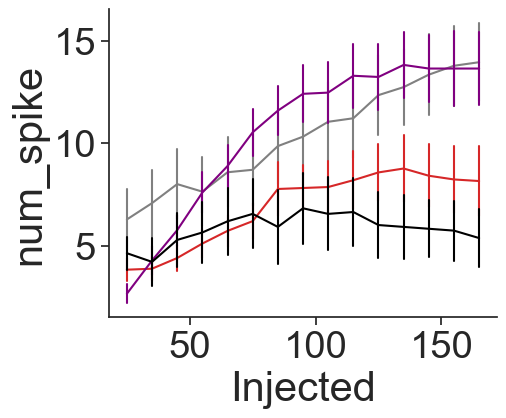

In [97]:
plot_df = df_all[df_all.state.isin(['Pre', 'Agg+', 'NPY-KD', 'ZD7288'])]
fig, ax = plt.subplots(figsize = [5,4])

palette = ['gray', 'Tab:red', 'Tab:blue', 'Tab:orange', 'purple', 'purple', 'black']


sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", errorbar=("se", 1))

leg = ax.get_legend()
if leg:
    leg.remove()

sns.despine()
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}_pharma.pdf',dpi=300,bbox_inches='tight', transparent=True)



In [ ]:
model = smf.ols('num_spike ~ C(Injected) * C(state)', data=df_all).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),8002.648876,14.0,9.421390,1.324737e-19
C(state),9636.998393,2.0,79.418386,2.427708e-32
C(Injected):C(state),2055.399897,28.0,1.209895,2.101096e-01
Residual,51450.143346,848.0,NaN,NaN


In [ ]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
# m_comp._results_table

# Estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     15   27
E                       2       3      2    7
M                       2       6     14   22
P                       6       6     11   23
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    18      27     55  100
0.8443773071908964
I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   0       1      0    1
D                   2       7      6   15
E                   3       1      0    4
M                   2      10      3   15
P                   1       3      2    6
All                 8      22     11   41
0.17888737857066916


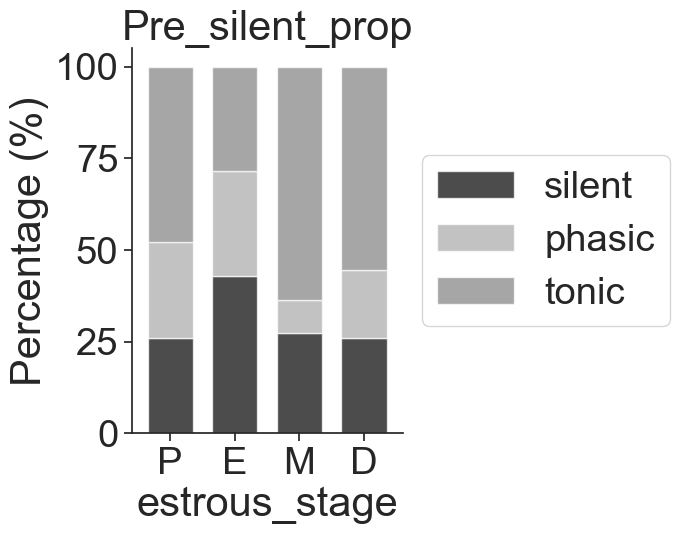

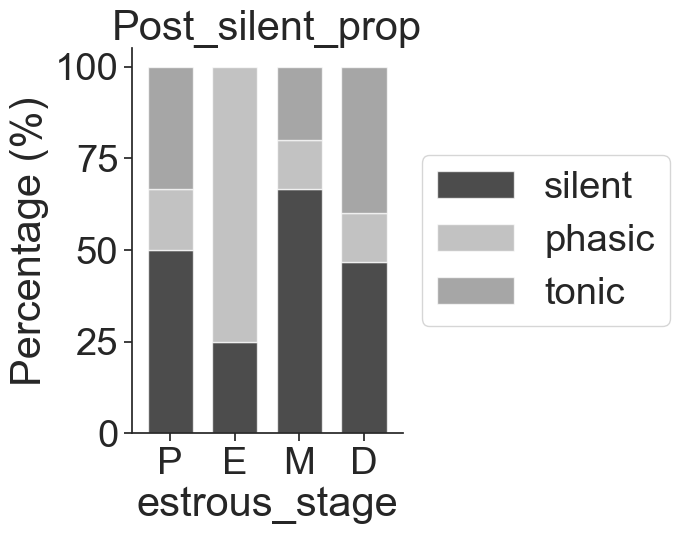

In [53]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre']: #Post Pre --> change filename accordingly
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,3), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('% silent neurons', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,60) 
    plt.yticks([0, 60, 30])
    ax.get_legend().remove()
#     ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_pre.pdf',
                dpi=300,bbox_inches='tight', transparent=True)

0.9794583218927253 0.020541678107274697


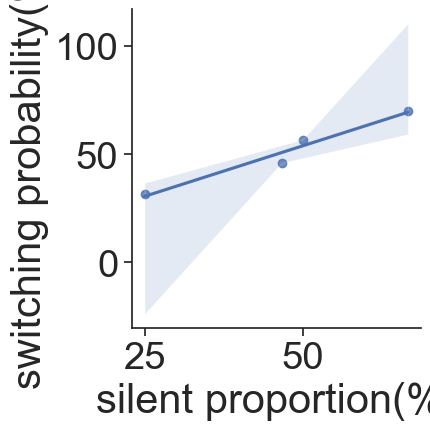

In [ ]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [148]:
# import multiple comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Ih_at_-120mV 0.01761554472149117
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E   0.3376 0.9993  -6.7879  7.4631  False
     D      M  -5.7214  0.022 -10.8225 -0.6203   True
     D      P   -0.911 0.9719  -6.4304  4.6084  False
     E      M   -6.059  0.126 -13.2289  1.1109  False
     E      P  -1.2487 0.9709   -8.722  6.2246  False
     M      P   4.8103 0.1143  -0.7663 10.3869  False
-----------------------------------------------------


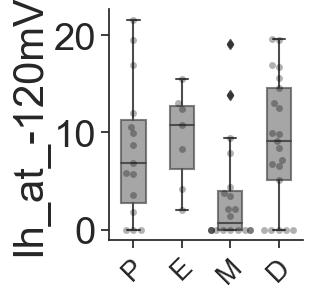

In [166]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
        
            
            

            
            if p < 0.05:
                print(column , p)
                state_df = state_df.loc[:, ['estrous_stage', column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(endog=state_df[column],
                                         groups=state_df['estrous_stage'],
                                        alpha=0.05)
                print(multiple_comp_result.summary())

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

In [ ]:
# state_df

In [ ]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
group_counts = state_df['estrous_stage'].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby('estrous_stage')['ID_mouse'].nunique()
print(f"Mouse numbers: \n{unique_counts}")

cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  11   11   22
E                   4    4    8
M                  17    5   22
P                  11    5   16
P to E              4    1    5
VS to be stained    1    0    1
not taken           2    2    4
All                51   31   82
0.3148191257490245
cat_categ estrous_stage         no        yes
4                     P  68.750000  31.250000
2                     E  50.000000  50.000000
3                     M  77.272727  22.727273
1                     D  50.000000  50.000000


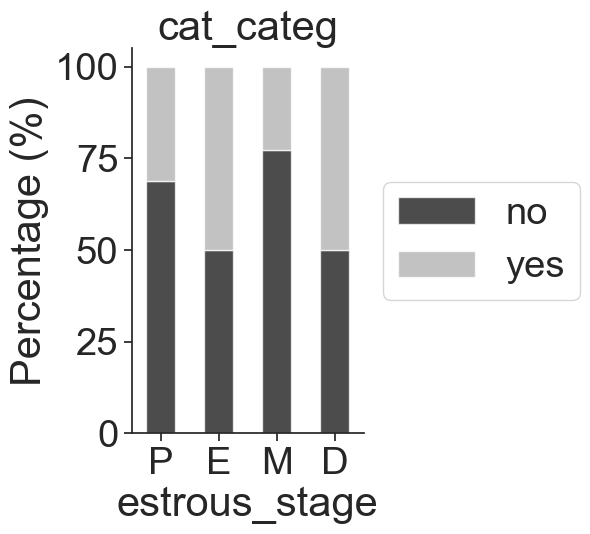

0.9272437748507365 0.0727562251492635


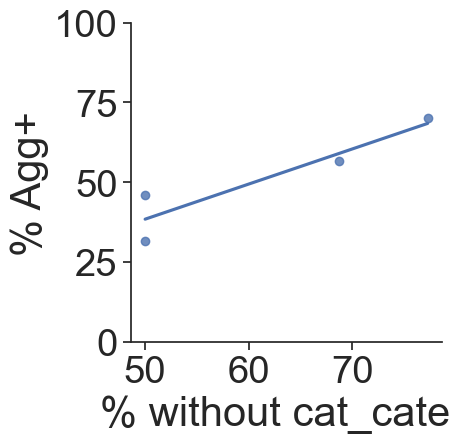

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   3   13   16
P to E              2    3    5
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.04500893177531009
IH estrous_stage         no         yes
4              P  18.750000   81.250000
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  22.727273   77.272727


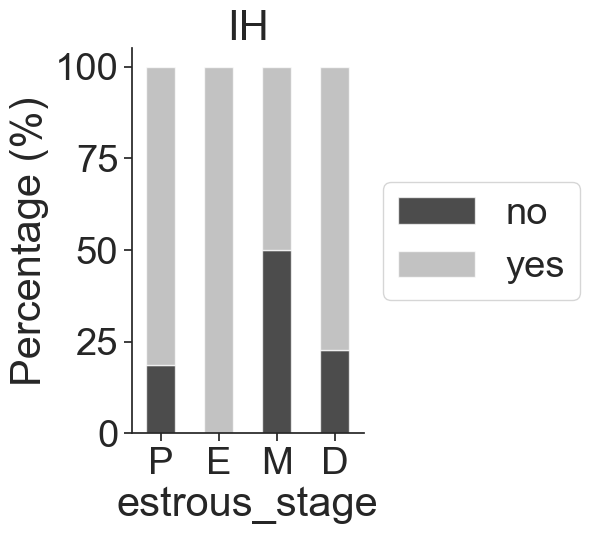

0.9298147165358119 0.07018528346418806


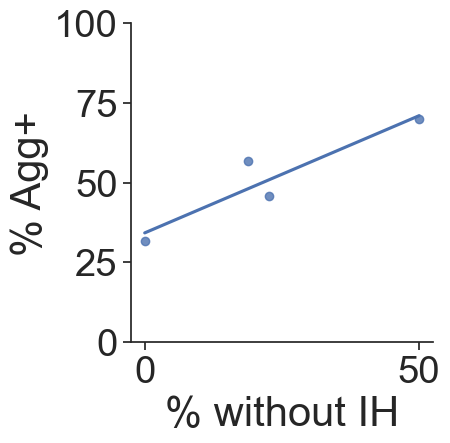

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  0   1    5    6
P to E             1   2    2    5
VS to be stained   0   0    1    1
All                1  15   27   43
0.5699800539341484
Adaptive estrous_stage         no        yes
4                    P  16.666667  83.333333
2                    E  50.000000  50.000000
3                    M  38.888889  61.111111
1                    D  40.000000  60.000000


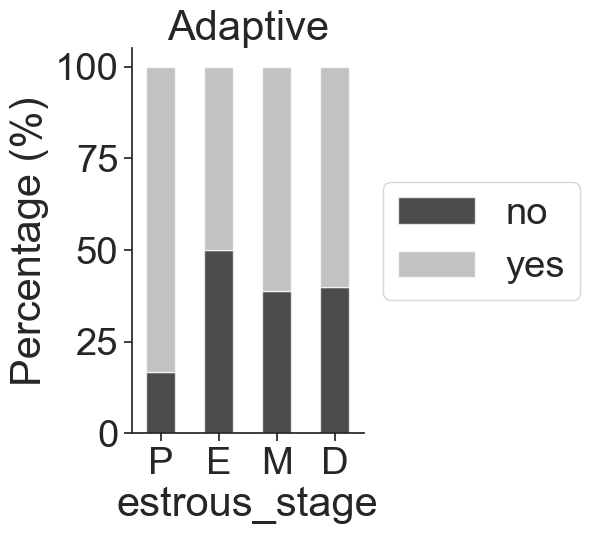

-0.5046834382039402 0.49531656179605976


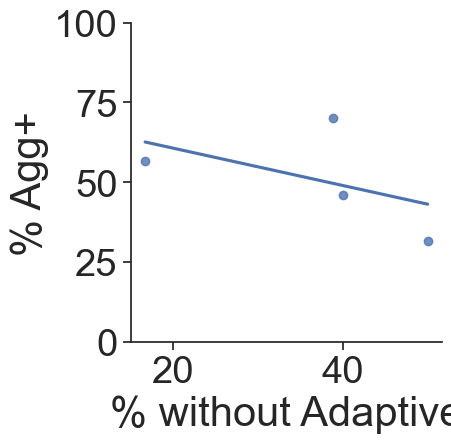

In [ ]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None, )
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
#     plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/{column}_switching_corr.pdf',
            dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   16   21
E                   0    7    7
M                  10   10   20
P                   5   15   20
VS to be stained    1    0    1
not taken           2    2    4
All                23   54   77
0.056205483511176685
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    5    9
E                  0   1    0    1
M                  0   7   10   17
P                  1   3    6   10
VS to be stained   0   0    1    1
All                1  15   23   39
0.803662355695632
-0.4469053317142255 0.5530946682857745


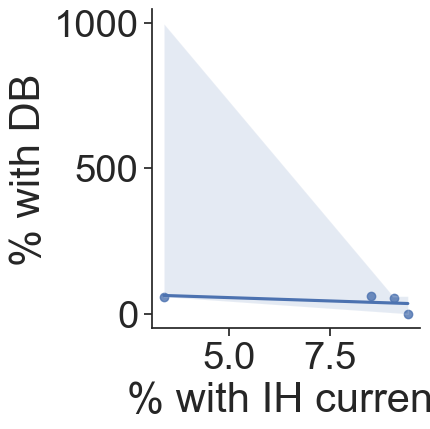

In [57]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()

## Individual plots

### Pre

In [110]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [111]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 20 from 7 mice
Number of E neurons: 8 from 3 mice
Number of M neurons: 25 from 6 mice
Number of D neurons: 28 from 3 mice


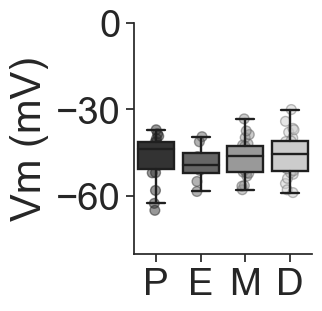

In [112]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

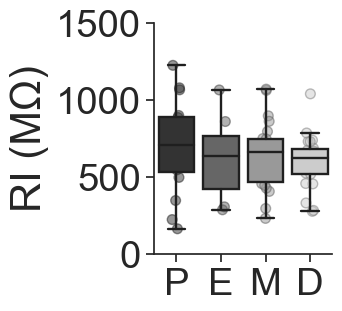

In [113]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

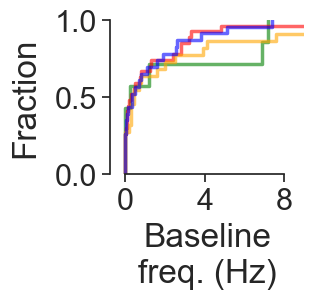

In [62]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_pre.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

### Post (Agg+/- pooled)

In [106]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [107]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 10 from 1 mice
Number of D neurons: 8 from 2 mice


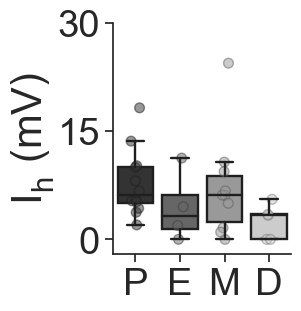

In [109]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=1)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ih_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

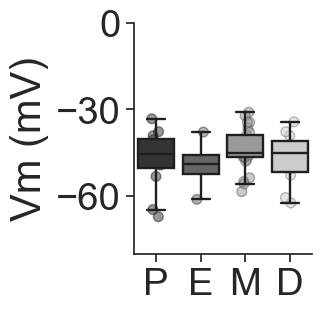

In [66]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

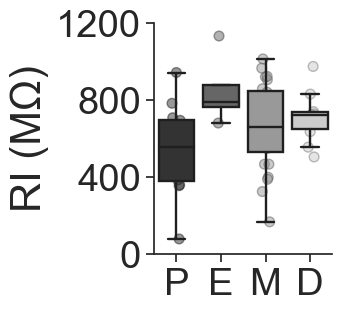

In [67]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

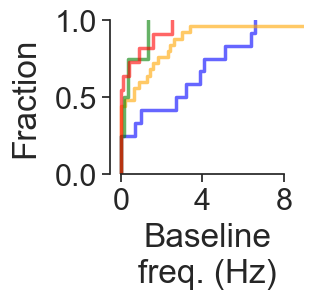

In [68]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_post.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# NPY administration

In [71]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [72]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of NPY neurons: 11 from 4 mice


In [73]:
# ephys_npy

In [74]:
ephys_npy.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

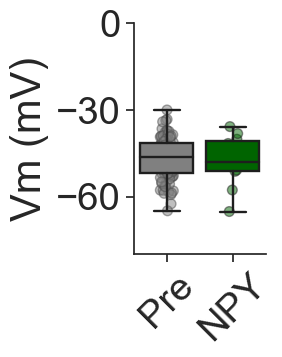

In [75]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

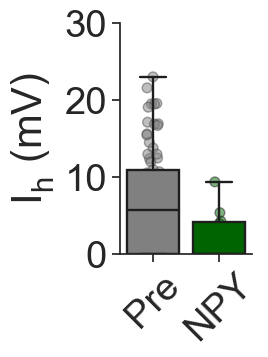

In [76]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

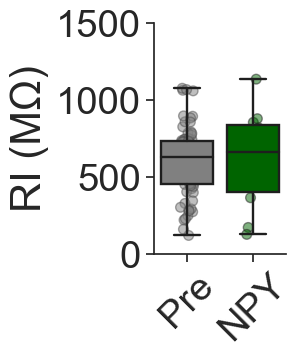

In [77]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [78]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
npy_100              2       7      2   11
All                 20      34     57  111
0.03082748617552394


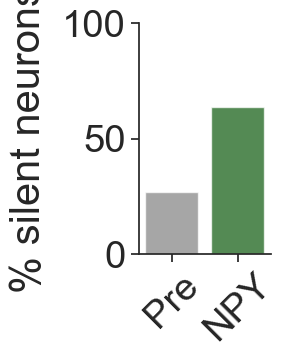

In [79]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [80]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

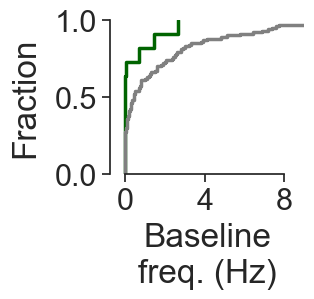

In [81]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# AgRP administration

In [82]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [83]:
# ephys_agrp.Behaviour_6hFD.unique()
# WE EXPECT 15 neurons from 5 mice

In [84]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of AgRP neurons: 15 from 5 mice


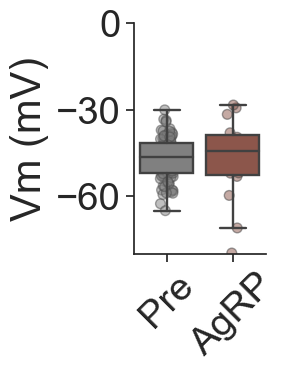

In [85]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

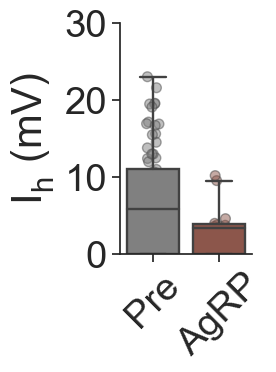

In [86]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

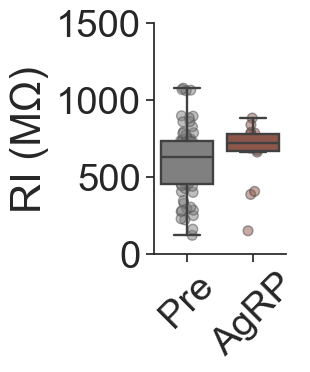

In [87]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [88]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp_100']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
agrp_100             2       5      8   15
All                 20      32     63  115
0.8361193092718071


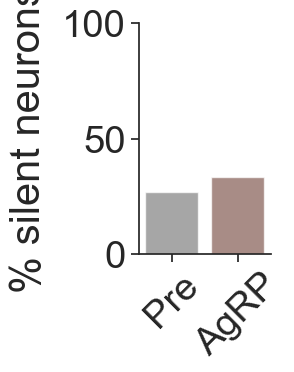

In [89]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp_100'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [90]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp_100')]

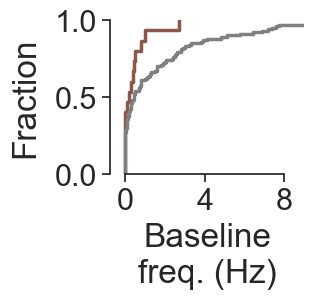

In [91]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)